# Preprocess dataset

## 1. Import and downloads

In [1]:
from transformers import (
    CLIPTokenizer,
    CLIPImageProcessor,
    DataCollatorWithPadding,
)
from datasets import load_dataset, concatenate_datasets, DatasetDict
from torch.utils.data import DataLoader
from PIL import Image, ImageDraw
from torchvision import transforms

In [2]:
MODEL_NAME = "openai/clip-vit-base-patch32"

In [3]:
ds = load_dataset("lmms-lab/RefCOCO")
ds

DatasetDict({
    val: Dataset({
        features: ['question_id', 'image', 'question', 'answer', 'segmentation', 'bbox', 'iscrowd', 'file_name'],
        num_rows: 8811
    })
    test: Dataset({
        features: ['question_id', 'image', 'question', 'answer', 'segmentation', 'bbox', 'iscrowd', 'file_name'],
        num_rows: 5000
    })
    testA: Dataset({
        features: ['question_id', 'image', 'question', 'answer', 'segmentation', 'bbox', 'iscrowd', 'file_name'],
        num_rows: 1975
    })
    testB: Dataset({
        features: ['question_id', 'image', 'question', 'answer', 'segmentation', 'bbox', 'iscrowd', 'file_name'],
        num_rows: 1810
    })
})

In [4]:
combined_ds = concatenate_datasets([ds["val"], ds["test"], ds["testA"], ds["testB"]])
combined_ds

Dataset({
    features: ['question_id', 'image', 'question', 'answer', 'segmentation', 'bbox', 'iscrowd', 'file_name'],
    num_rows: 17596
})

In [5]:
combined_ds[0]

{'question_id': '1537681',
 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x428>,
 'question': 'Please carefully observe the area circled in the image and come up with a caption for the area.',
 'answer': ['bowl behind the others can only see part',
  'Dish in top right corner',
  'White dish in the top right corner.',
  'white pot upper right corner'],
 'segmentation': [468.29998779296875,
  2.8299999237060547,
  471.17999267578125,
  46.0099983215332,
  473.1000061035156,
  83.44000244140625,
  521.0900268554688,
  107.43000030517578,
  580.5800170898438,
  117.02999877929688,
  640.0,
  106.47000122070312,
  640.0,
  104.55000305175781,
  640.0,
  0.9100000262260437],
 'bbox': [468.29998779296875,
  0.9100000262260437,
  171.6999969482422,
  116.12000274658203],
 'iscrowd': 0,
 'file_name': 'COCO_train2014_000000580957_4.jpg'}

In [6]:
tokenizer = CLIPTokenizer.from_pretrained(MODEL_NAME)
processor = CLIPImageProcessor.from_pretrained(MODEL_NAME)
to_tensor = transforms.ToTensor()

## 2. Process raw data to tensors

In [7]:
def process_data(batch):
    images = batch["image"]
    texts = [" . ".join(answers) for answers in batch["answer"]]
    polygons = batch["segmentation"]

    image_inputs = processor(images)
    text_inputs = tokenizer(texts, truncation=True)
    seg_masks = []

    for image, polygon in zip(images, polygons):
        mask_img = Image.new("1", image.size)
        img_draw = ImageDraw.Draw(mask_img)
        vertices = [
            (polygon[i * 2], polygon[i * 2 + 1]) for i in range(len(polygon) // 2)
        ]
        img_draw.polygon(vertices, fill=1)
        mask_tensor = to_tensor(mask_img.resize((224, 224))).bool()
        seg_masks.append(mask_tensor)

    return {
        "pixel_values": image_inputs["pixel_values"],
        "input_ids": text_inputs["input_ids"],
        "attention_mask": text_inputs["attention_mask"],
        "seg_masks": seg_masks,
    }

In [8]:
processed_ds = combined_ds.map(
    process_data,
    batched=True,
    remove_columns=combined_ds.column_names,
)
processed_ds

Dataset({
    features: ['pixel_values', 'input_ids', 'attention_mask', 'seg_masks'],
    num_rows: 17596
})

In [9]:
dataloader = DataLoader(
    processed_ds,
    batch_size=16,
    num_workers=2,
    collate_fn=DataCollatorWithPadding(tokenizer),
)

## 3. View data after mapping

In [10]:
x = None
for batch in dataloader:
    x = batch
    break

In [11]:
x["pixel_values"].shape

torch.Size([16, 3, 224, 224])

In [12]:
x["input_ids"].shape

torch.Size([16, 31])

In [13]:
x["attention_mask"].shape

torch.Size([16, 31])

In [14]:
x["seg_masks"][0]

tensor([[[False, False, False,  ..., False, False, False],
         [False, False, False,  ...,  True,  True,  True],
         [False, False, False,  ...,  True,  True,  True],
         ...,
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False]]])

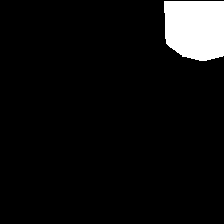

In [15]:
transforms.ToPILImage()(x["seg_masks"][0].float())

## 4. Spliting data train/val/test

In [16]:
split_1 = processed_ds.train_test_split(0.2)
split_2 = split_1["test"].train_test_split(0.5)

ds_train = split_1["train"]
ds_val = split_2["train"]
ds_test = split_2["test"]

ds_dict = DatasetDict({"train": ds_train, "val": ds_val, "test": ds_test})
ds_dict

DatasetDict({
    train: Dataset({
        features: ['pixel_values', 'input_ids', 'attention_mask', 'seg_masks'],
        num_rows: 14076
    })
    val: Dataset({
        features: ['pixel_values', 'input_ids', 'attention_mask', 'seg_masks'],
        num_rows: 1760
    })
    test: Dataset({
        features: ['pixel_values', 'input_ids', 'attention_mask', 'seg_masks'],
        num_rows: 1760
    })
})

## 5. Saving processed dataset 

In [17]:
ds_dict.save_to_disk("./.dataset")

Saving the dataset (0/18 shards):   0%|          | 0/14076 [00:00<?, ? examples/s]

Saving the dataset (0/3 shards):   0%|          | 0/1760 [00:00<?, ? examples/s]

Saving the dataset (0/3 shards):   0%|          | 0/1760 [00:00<?, ? examples/s]

In [18]:
from datasets import load_from_disk

load_from_disk("./.dataset/")

Loading dataset from disk:   0%|          | 0/18 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['pixel_values', 'input_ids', 'attention_mask', 'seg_masks'],
        num_rows: 14076
    })
    val: Dataset({
        features: ['pixel_values', 'input_ids', 'attention_mask', 'seg_masks'],
        num_rows: 1760
    })
    test: Dataset({
        features: ['pixel_values', 'input_ids', 'attention_mask', 'seg_masks'],
        num_rows: 1760
    })
})